# Portfolio Backtesting

Portfolio optimization was performed using historical data.

To evaluate whether the optimized portfolio generalizes to unseen data, a backtesting framework is implemented.

The data is divided into:

- Training Period (2019–2022)
- Testing Period (2023–2024)

Portfolio weights are determined using only the training period and evaluated on the testing period.

In [12]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [13]:
data = pd.read_csv(
    '../data/stock_prices.csv',
    index_col='Date',
    parse_dates=True
)

data.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2019-01-02,37.469200,76.956497,52.270512,94.193161,3.373053
2019-01-03,33.736984,75.014000,50.822834,90.727974,3.169262
2019-01-04,35.177208,78.769501,53.429722,94.947655,3.372309
2019-01-07,35.098904,81.475502,53.323174,95.068748,3.550841
2019-01-08,35.767998,82.829002,53.791519,95.758064,3.462443


In [14]:
stocks = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL']

## Train-Test Split

In [15]:
train_data = data.loc[:'2022-12-31']

test_data = data.loc['2023-01-01':]

In [16]:
#compute returns

train_returns = train_data.pct_change().dropna()

test_returns = test_data.pct_change().dropna()

## Training and Testing Returns

Training returns are used for portfolio construction.

Testing returns are used exclusively for evaluating future performance and preventing look-ahead bias.

In [17]:
#compute training statistics

annual_returns_train = train_returns.mean() * 252

covariance_matrix_train = train_returns.cov() * 252

## Portfolio Optimization Using Training Data

Portfolio optimization is performed using only the training period (2019–2022).

Monte Carlo simulation generates thousands of random portfolios, each with a unique allocation across the selected assets.

For every portfolio, the following metrics are computed:

- Expected Return
- Portfolio Volatility
- Sharpe Ratio

The portfolio with the highest Sharpe Ratio is selected for out-of-sample testing.

In [18]:
num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpes = []
portfolio_weights = []

risk_free_rate = 0.04

In [19]:
for _ in range(num_portfolios):

    # Generate random weights
    weights = np.random.random(len(stocks))

    # Normalize weights so they sum to 1
    weights /= np.sum(weights)

    # Store weights
    portfolio_weights.append(weights)

    # Portfolio return
    portfolio_return = np.dot(
        weights,
        annual_returns_train
    )

    # Portfolio variance
    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix_train, weights)
    )

    # Portfolio volatility
    portfolio_volatility = np.sqrt(portfolio_variance)

    # Sharpe ratio
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    # Store results
    portfolio_returns.append(portfolio_return)
    portfolio_volatilities.append(portfolio_volatility)
    portfolio_sharpes.append(sharpe_ratio)

In [20]:
portfolio_df = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatilities,
    'Sharpe Ratio': portfolio_sharpes
})

portfolio_df.head()

,Return,Volatility,Sharpe Ratio
0,0.285112,0.319905,0.766202
1,0.292091,0.339479,0.742582
2,0.187306,0.308244,0.477886
3,0.311880,0.326492,0.832730
4,0.293424,0.334960,0.756580


In [21]:
#finding maximum sharpe ratio
max_sharpe_idx = portfolio_df['Sharpe Ratio'].idxmax()

max_sharpe_portfolio = portfolio_df.loc[max_sharpe_idx]

max_sharpe_portfolio

Return          0.385013
Volatility      0.354490
Sharpe Ratio    0.973266
Name: 4596, dtype: float64

In [22]:
max_sharpe_weights = portfolio_weights[max_sharpe_idx]

max_sharpe_weights

array([0.60807128, 0.01101626, 0.03128508, 0.09286779, 0.25675959])

In [23]:
optimal_weights = pd.DataFrame({
    'Stock': stocks,
    'Weight (%)': max_sharpe_weights * 100
})

optimal_weights['Weight (%)'] = (
    optimal_weights['Weight (%)']
    .round(2)
)

optimal_weights

,Stock,Weight (%)
0,AAPL,60.81
1,MSFT,1.10
2,NVDA,3.13
3,AMZN,9.29
4,GOOGL,25.68


In [24]:
optimal_weights['Weight (%)'].sum()

np.float64(100.01000000000002)

## Apply Portfolio to Test Data

In [25]:
optimized_portfolio_returns = np.dot(
    test_returns,
    max_sharpe_weights
)

In [26]:
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_weight_returns = np.dot(
    test_returns,
    equal_weights
)

In [27]:
#convert to series
optimized_portfolio_returns = pd.Series(
    optimized_portfolio_returns,
    index=test_returns.index
)

equal_weight_returns = pd.Series(
    equal_weight_returns,
    index=test_returns.index
)

In [29]:
#cumulative returns
optimized_cumulative = (
    1 + optimized_portfolio_returns
).cumprod()

equal_weight_cumulative = (
    1 + equal_weight_returns
).cumprod()


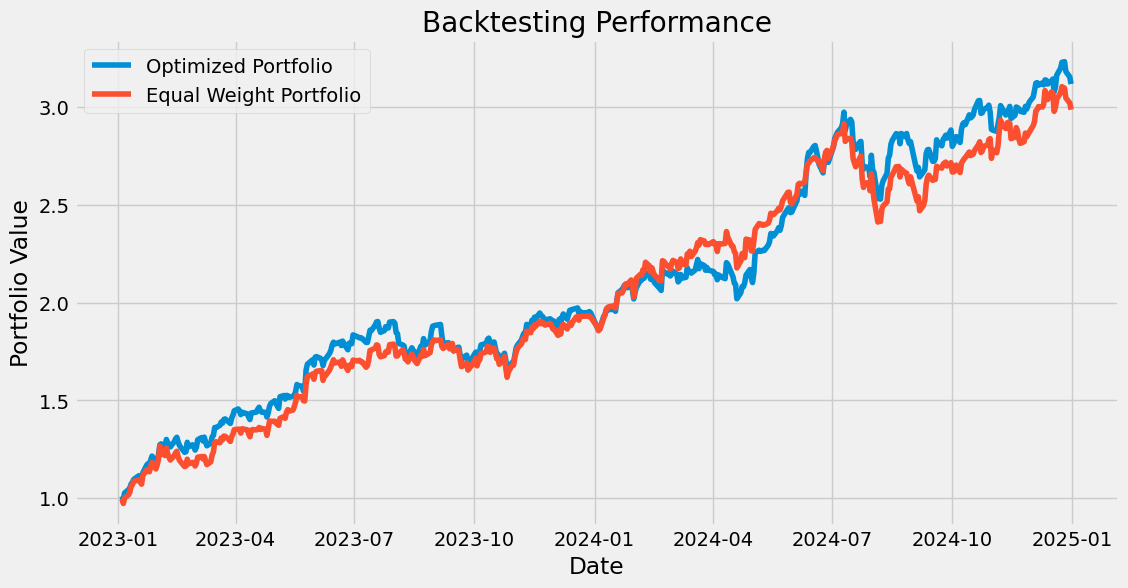

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    optimized_cumulative,
    label='Optimized Portfolio'
)

plt.plot(
    equal_weight_cumulative,
    label='Equal Weight Portfolio'
)

plt.title('Backtesting Performance')

plt.xlabel('Date')

plt.ylabel('Portfolio Value')

plt.legend()

plt.savefig('../images/backtesting_performance.png',
            bbox_inches='tight')

plt.show()

Train-test splitting prevents look-ahead bias by ensuring that portfolio weights are determined using only historical information. The testing period provides an unbiased evaluation of how the portfolio would have performed on unseen future data.

In [ ]:
optimized_return = optimized_portfolio_returns.mean() * 252

optimized_volatility = optimized_portfolio_returns.std() * np.sqrt(252)

optimized_sharpe = (
    optimized_return - risk_free_rate
) / optimized_volatility

print("Return:", optimized_return)
print("Volatility:", optimized_volatility)
print("Sharpe:", optimized_sharpe)

Return: 0.5996797352565737
Volatility: 0.23271270298404606
Sharpe: 2.4050244274587076


In [33]:
optimized_portfolio_returns.to_csv(
    '../data/optimized_returns.csv'
)

In [32]:
equal_return = equal_weight_returns.mean() * 252

equal_volatility = equal_weight_returns.std() * np.sqrt(252)

equal_sharpe = (
    equal_return - risk_free_rate
) / equal_volatility

print("Return:", equal_return)
print("Volatility:", equal_volatility)
print("Sharpe:", equal_sharpe)

Return: 0.5782517788849171
Volatility: 0.23366048745593979
Sharpe: 2.303563536759344


# Conclusion

A portfolio optimization framework was developed using Modern Portfolio Theory and Monte Carlo simulation.

Historical stock data from Apple, Microsoft, Nvidia, Amazon, and Google was used to estimate expected returns and covariance relationships.

The analysis included:

- Return and volatility estimation
- Correlation and covariance analysis
- Monte Carlo portfolio simulation
- Efficient Frontier construction
- Maximum Sharpe Ratio optimization
- Out-of-sample backtesting

Backtesting results demonstrated that the optimized portfolio achieved higher returns and a superior Sharpe Ratio compared to an equal-weight benchmark, indicating improved risk-adjusted performance.

The project highlights the importance of diversification, portfolio construction, and quantitative methods in investment decision-making.